In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [3]:
import numpy as np
import os
import pandas as pd
import cv2
from PIL import Image
import scipy

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import *
from sklearn.neural_network import MLPClassifier
# import pydot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
import tensorflow.keras.backend as K

from tqdm import tqdm, tqdm_notebook
from colorama import Fore
import json
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from skimage.io import *
%config Completer.use_jedi = False
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from time import perf_counter
import seaborn as sns

def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

print("All modules have been imported")

All modules have been imported


In [4]:
# ============================================================================
# GENERIC DATASET CONFIGURATION
# ----------------------------------------------------------------------------
# This is the ONLY cell you should need to edit to reuse this notebook on a
# new dataset. Everything below (feature extraction, CNN backbones, DNN
# classifier, evaluation metrics, comparison table, best-model selection)
# is unchanged and will pick up NUMBER_OF_CLASSES / IMAGE_SIZE automatically.
# ============================================================================

DATASET_PATH = "./dataset"      # must contain train/, test/ (and optionally val/) subfolders,
                                 # each containing one subfolder per class
IMAGE_SIZE = (224, 224)         # (height, width) fed to the CNN backbones
NUMBER_OF_CLASSES = 2           # number of class subfolders under train/
FEATURE_BATCH_SIZE = 8           # batch size used when extracting CNN features via model_feat.predict()
                                 # (predicting on the full array at once can exceed GPU memory / trigger
                                 # "Failed copying input tensor from CPU to GPU" errors on some setups)
MIN_VAL_SIZE = 200               # if the dataset's own val/ folder has fewer images than this, it is
                                 # considered too small to give a meaningful validation signal, and a
                                 # validation split is carved out of train/ instead (see loader below)

print(f"Dataset path: {DATASET_PATH}")
print(f"Image size:   {IMAGE_SIZE}")
print(f"Classes:      {NUMBER_OF_CLASSES}")

Dataset path: ./dataset
Image size:   (224, 224)
Classes:      2


In [5]:
# ============================================================================
# GENERIC DATASET LOADER
# ----------------------------------------------------------------------------
# MODIFICATION: this replaces the original Retina-specific loader, which
# assumed:
#   - a single flat folder of PNGs read via a CSV / folder-name mapping to
#     the fixed labels No_DR / Mild / Moderate / Severe / Proliferate_DR
#   - one directory (`colored_images`) that had to be manually re-split
#     into train/val/test with train_test_split()
#
# This dataset (and the folder layout you described) already ships with
# train/, test/, val/ folders, each containing one subfolder per class
# (e.g. dataset/train/NORMAL, dataset/train/PNEUMONIA). So instead of
# re-splitting a flat folder, this loader:
#   1. Discovers classes automatically from the subfolder names under
#      DATASET_PATH/train (sorted alphabetically -> stable numeric label
#      assignment, e.g. NORMAL=0, PNEUMONIA=1)
#   2. Walks train/, val/, test/ separately, reading every image + its
#      class label
#   3. Falls back to carving a validation split out of train/ if no val/
#      folder exists (so the same loader also works on 2-way train/test
#      datasets)
#
# Everything downstream still receives plain numpy arrays named
# x_train / x_val / x_test / y_train / y_val / y_test -- identical
# variable names to the original notebook, so no other cell needs to change.
# ============================================================================

import os
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

DATASET_PATH_OBJ = Path(DATASET_PATH)


def discover_classes(split_dir: Path):
    """Auto-discover class names from subfolder names, sorted for a stable
    (reproducible) label ordering."""
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not classes:
        raise ValueError(f"No class subfolders found under {split_dir}")
    return classes


def load_split(split_dir: Path, class_to_idx: dict, image_size):
    """Read every image under split_dir/<class_name>/* into arrays."""
    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue  # skip unreadable / non-image files
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)
    return np.asarray(images), np.asarray(labels)


# --- Discover classes from the train/ folder --------------------------------
train_dir = DATASET_PATH_OBJ / "train"
test_dir = DATASET_PATH_OBJ / "test"
val_dir = DATASET_PATH_OBJ / "val"

class_names = discover_classes(train_dir)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

assert len(class_names) == NUMBER_OF_CLASSES, (
    f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
    f"class folders were found under {train_dir}: {class_names}. "
    f"Update NUMBER_OF_CLASSES in the config cell to match."
)
print(f"Discovered classes: {class_to_idx}")

# --- Load train split ---------------------------------------------------
x_train, y_train = load_split(train_dir, class_to_idx, IMAGE_SIZE)

# --- Load test split ---------------------------------------------------
x_test, y_test = load_split(test_dir, class_to_idx, IMAGE_SIZE)

# --- Load (or carve out) a validation split ------------------------------
# MODIFICATION: some datasets ship a val/ folder that exists but is too
# small to give a meaningful validation signal (e.g. the standard Chest
# X-Ray Pneumonia Kaggle release ships only 16 val images total -- 8 per
# class). Training against a validation set that small can look like the
# model "isn't learning" (accuracy stuck at a suspicious round number)
# purely from sample-size noise, not a real problem with the model. So:
# only use the dataset's own val/ folder if it meets MIN_VAL_SIZE; below
# that threshold, carve a validation split out of train/ instead, the same
# way the loader already does when val/ is missing entirely.
def count_images(split_dir: Path, class_names):
    """Count image files under split_dir/<class_name>/* without loading them."""
    total = 0
    for name in class_names:
        class_dir = split_dir / name
        if class_dir.exists():
            total += sum(1 for p in class_dir.glob("**/*") if p.is_file())
    return total


val_images_on_disk = count_images(val_dir, class_names) if val_dir.exists() else 0

if val_dir.exists() and val_images_on_disk >= MIN_VAL_SIZE:
    x_val, y_val = load_split(val_dir, class_to_idx, IMAGE_SIZE)
else:
    if val_dir.exists() and val_images_on_disk > 0:
        print(f"val/ folder found but only has {val_images_on_disk} images "
              f"(below MIN_VAL_SIZE={MIN_VAL_SIZE}) -- splitting a validation "
              f"set out of train/ instead")
    else:
        print("No val/ folder found -- splitting a validation set out of train/")
    x_train, x_val, y_train, y_val = train_test_split(
        x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )

print(f"Successfully loaded {len(x_train) + len(x_val) + len(x_test)} images "
      f"across {len(class_names)} classes!")
print(len(x_train), len(x_val), len(x_test))


Discovered classes: {'NORMAL': 0, 'PNEUMONIA': 1}
val/ folder found but only has 16 images (below MIN_VAL_SIZE=200) -- splitting a validation set out of train/ instead
Successfully loaded 5840 images across 2 classes!
4433 783 624


In [6]:
# ============================================================================
# ROBUSTNESS CHECKS
# ----------------------------------------------------------------------------
# Extra assertions confirming the generic config actually matches what was
# loaded, before any CNN/feature-extraction cells run.
# ============================================================================

assert NUMBER_OF_CLASSES == len(class_names), (
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) does not match discovered "
    f"classes ({len(class_names)}): {class_names}"
)

assert set(y_train.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_train contains label values outside range(NUMBER_OF_CLASSES) -- "
    "check class_to_idx mapping."
)
assert set(y_val.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_val contains label values outside range(NUMBER_OF_CLASSES)."
)
assert set(y_test.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_test contains label values outside range(NUMBER_OF_CLASSES)."
)

print("All robustness checks passed: "
      f"{len(class_names)} classes, labels within expected range.")


All robustness checks passed: 2 classes, labels within expected range.


In [7]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(4433, 224, 224, 3)
(783, 224, 224, 3)
(624, 224, 224, 3)


# DNN Model

In [8]:
# Defining our DNN Model
# ============================================================================
# MODIFICATION: this cell used to build a single dnn_model instance, hardcoded
# for a fixed input width, and every architecture block below reused that
# SAME instance -- refitting already-trained weights on top of a different
# CNN's features each time, and never resetting between blocks.
#
# This is now a factory function: build_dnn_model(input_dim) returns a FRESH,
# untrained model sized to whatever the actual feature vector width is for
# that architecture. Each of the 11 CNN blocks below calls this with its own
# train_features.shape[1] -- no hardcoded input_dim, no shared weights
# between architectures, and the model summary is unaffected: same layer
# stack, same layer sizes, same output activation as the original.
# ============================================================================

def build_dnn_model(input_dim, number_of_classes):
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer='HeUniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(256, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(number_of_classes, activation='softmax'))
    return model


# Build one instance now just to show the architecture (summary only --
# each CNN block below builds its OWN fresh instance for actual training).
dnn_model = build_dnn_model(input_dim=NUMBER_OF_CLASSES, number_of_classes=NUMBER_OF_CLASSES)
dnn_model.summary()


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,706 (299.63 KB)

 Trainable params: 76,706 (299.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)

In [10]:
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    y_pred_train = [1 if x>0.5 else 0 for x in y_pred_train]
    y_pred_val = [1 if x>0.5 else 0 for x in y_pred_val]
    y_pred_test = [1 if x>0.5 else 0 for x in y_pred_test]
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy)) 
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
                          
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
          
    print("-"*80)
    print()

In [11]:
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

# ResNet50

In [12]:
base_model= ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 84s 26ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [13]:
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
    
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
   
    print('------------------------ Test Set Metrics------------------------')
    print("Accuracy score : {}%".format(test_accuracy))
    
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [14]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.92%
------------------------ Validation Set Metrics------------------------

Accuracy score : 81.23%
------------------------ Test Set Metrics------------------------
Accuracy score : 65.06%

Accuracy score : 65.06%
F1_score : 0.61
Kappa Score : 0.17 
Recall score: 0.65
Precision score : 0.63
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.53%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.8%
------------------------ Test Set Metrics------------------------
Accuracy score : 66.83%

Accuracy score : 66.83%
F1_score : 0.61
Kappa Score 

In [15]:
train_y=to_categorical(
    y_train,
    NUMBER_OF_CLASSES
)
val_y=to_categorical(
    y_val,
    NUMBER_OF_CLASSES
)
test_y=to_categorical(
    y_test,
    NUMBER_OF_CLASSES
)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.8706 / 1.2112
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7708 - loss: 0.4955 - val_accuracy: 0.8276 - val_loss: 0.3960
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8281 - loss: 0.3915 - val_accuracy: 0.8314 - val_loss: 0.3754
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8416 - loss: 0.3704 - val_accuracy: 0.8327 - val_loss: 0.3805
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8383 - loss: 0.3676 - val_accuracy: 0.8148 - val_loss: 0.4355
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8484 - loss: 0.3559 - val_accuracy: 0.8161 - val_loss: 0.3735
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8484 - loss: 0.3538 - val_accuracy: 0.8301 - val_loss: 0.3562
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.3435 - val_accuracy: 0.8276 - val_loss: 0.3814
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8563 - loss: 0.3451 - val_accuracy: 

In [16]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred10 = np.argmax(y_pred_probs, axis=-1)
y_test10 = [np.argmax(x) for x in test_y]
y_pred_prb10 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test10, y_pred10), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test10, y_pred10), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test10, y_pred10, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.6827
Precision score is : 0.6775
Recall score is : 0.6827
F1 Score is : 0.6482
Cohen Kappa Score: 0.2443
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.66      0.32      0.43       234
   PNEUMONIA       0.69      0.90      0.78       390

    accuracy                           0.68       624
   macro avg       0.67      0.61      0.60       624
weighted avg       0.68      0.68      0.65       624



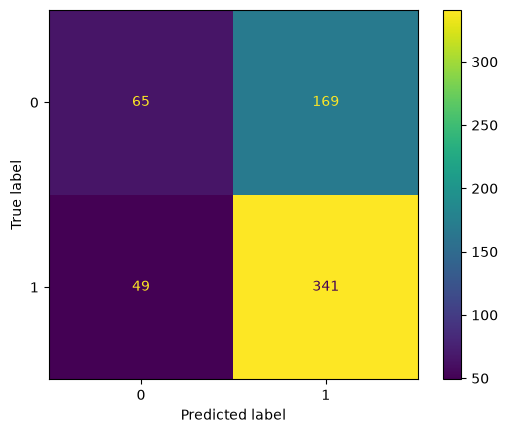

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the KNN model (using the parameters from the original notebook)
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)

# 2. Train the model
knn.fit(train_features, y_train)

# 3. Generate and display the confusion matrix using the estimator
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

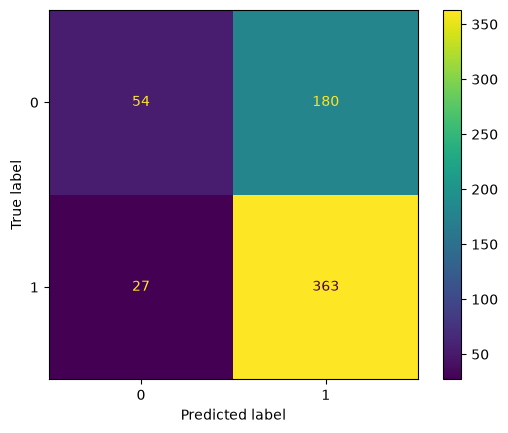

In [18]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

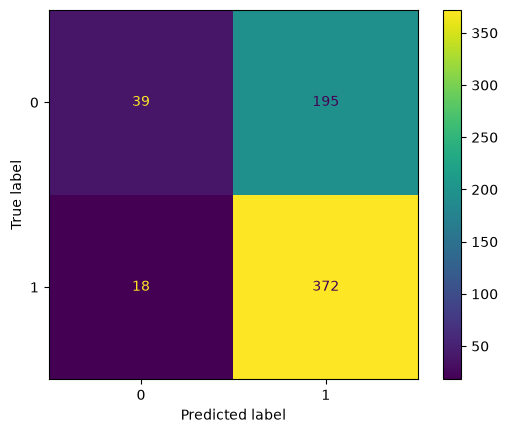

In [19]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

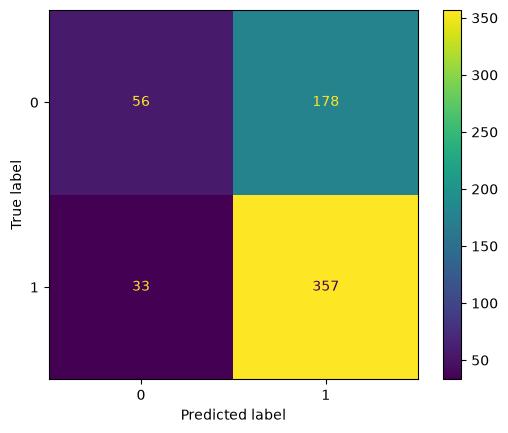

In [20]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

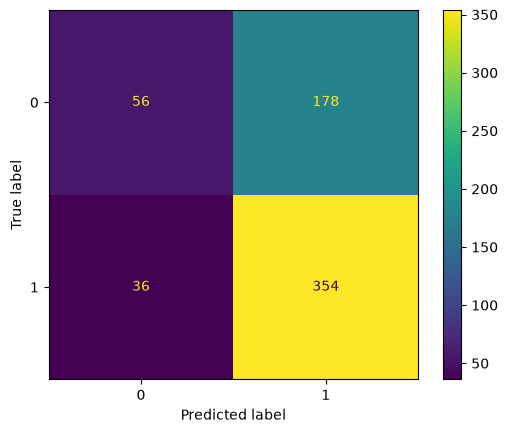

In [21]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# VGG-16

In [22]:
base_model= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [24]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.87%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.44%
------------------------ Test Set Metrics------------------------

Accuracy score : 70.19%
F1_score : 0.66
Kappa Score : 0.28 
Recall score: 0.7
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.42%
------------------------ Validation Set Metrics------------------------

Accuracy score : 86.97%
------------------------ Test Set Metrics------------------------

Accuracy score : 70.99%
F1_score : 0.67
Kappa Score : 0.3 
Recall score: 0.71
Precision score : 0.73

In [25]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='sgd',loss='categorical_crossentropy', metrics=['accuracy'],)
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 5.0971 / 7.1110
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7349 - loss: 0.5984 - val_accuracy: 0.7433 - val_loss: 0.5500
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7886 - loss: 0.4681 - val_accuracy: 0.8519 - val_loss: 0.3836
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8319 - loss: 0.3894 - val_accuracy: 0.8199 - val_loss: 0.4001
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8401 - loss: 0.3734 - val_accuracy: 0.8084 - val_loss: 0.4395
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8385 - loss: 0.3610 - val_accuracy: 0.7880 - val_loss: 0.4392
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8480 - loss: 0.3478 - val_accuracy: 0.8301 - val_loss: 0.3711
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8586 - loss: 0.3424 - val_accuracy: 0.8685 - val_loss: 0.3374
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8498 - loss: 0.3405 - val_accuracy: 0

In [26]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred2 = np.argmax(y_pred_probs, axis=-1)
y_test2 = [np.argmax(x) for x in test_y]
y_pred_prb2 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test2, y_pred2), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test2, y_pred2), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test2, y_pred2, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.7324
Precision score is : 0.7316
Recall score is : 0.7324
F1 Score is : 0.7152
Cohen Kappa Score: 0.3832
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.73      0.46      0.56       234
   PNEUMONIA       0.73      0.90      0.81       390

    accuracy                           0.73       624
   macro avg       0.73      0.68      0.68       624
weighted avg       0.73      0.73      0.72       624



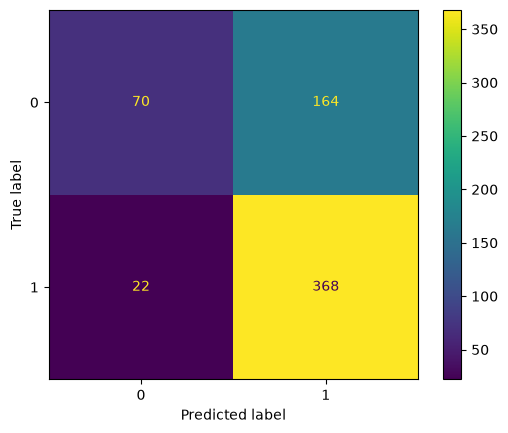

In [27]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

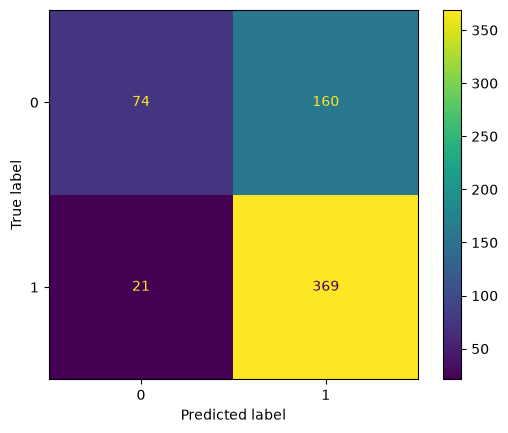

In [28]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

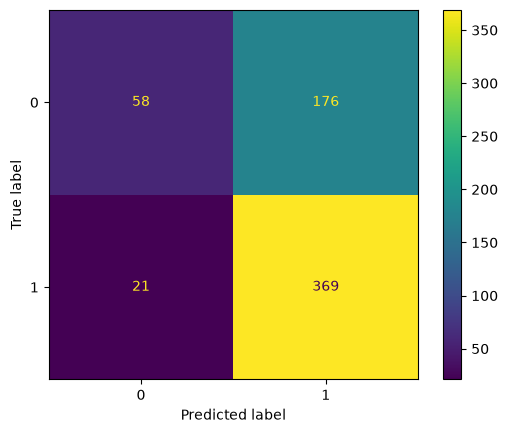

In [29]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

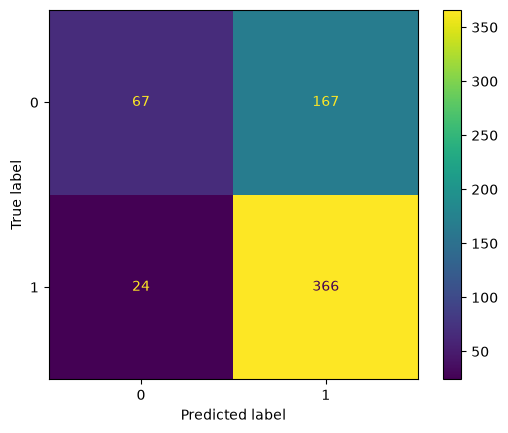

In [30]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

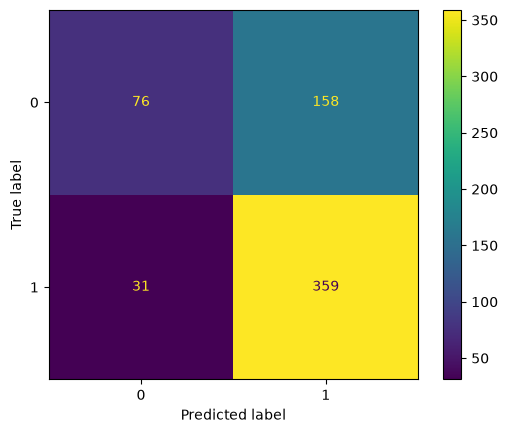

In [31]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

In [32]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# VGG-19

In [33]:
base_model= VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [35]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.37%
------------------------ Validation Set Metrics------------------------

Accuracy score : 80.33%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.07%
F1_score : 0.64
Kappa Score : 0.24 
Recall score: 0.69
Precision score : 0.71
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 85.56%
------------------------ Validation Set Metrics------------------------

Accuracy score : 83.39999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.39%
F1_score : 0.64
Kappa Score : 0.25 
Recall score: 0.69
Precisio

In [36]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 4.2038 / 6.8965
DNN input dimension (auto-detected): 64
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7695 - loss: 0.4792 - val_accuracy: 0.8161 - val_loss: 0.4262
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8141 - loss: 0.4165 - val_accuracy: 0.8110 - val_loss: 0.4127
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8270 - loss: 0.3839 - val_accuracy: 0.8008 - val_loss: 0.4118
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8213 - loss: 0.3800 - val_accuracy: 0.8263 - val_loss: 0.4040
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8356 - loss: 0.3678 - val_accuracy: 0.7969 - val_loss: 0.4370
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8365 - loss: 0.3610 - val_accuracy: 0.8097 - val_loss: 0.4151
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8468 - loss: 0.3457 - val_accuracy: 0.8097 - val_loss: 0.4055
Epoch 8/10
139/139 ━━━━━━━━━━

In [37]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred1 = np.argmax(y_pred_probs, axis=-1)
y_test1 = [np.argmax(x) for x in test_y]
y_pred_prb1 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test1, y_pred1), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test1, y_pred1), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test1, y_pred1, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.7147
Precision score is : 0.7172
Recall score is : 0.7147
F1 Score is : 0.6885
Cohen Kappa Score: 0.3283
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.73      0.38      0.50       234
   PNEUMONIA       0.71      0.91      0.80       390

    accuracy                           0.71       624
   macro avg       0.72      0.65      0.65       624
weighted avg       0.72      0.71      0.69       624



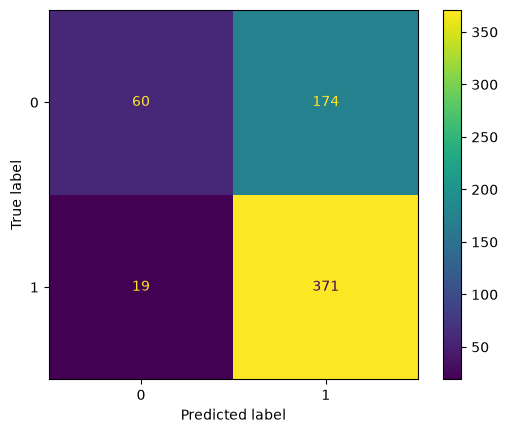

In [38]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

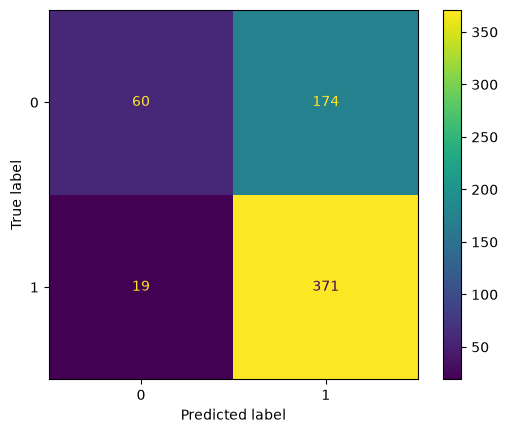

In [39]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

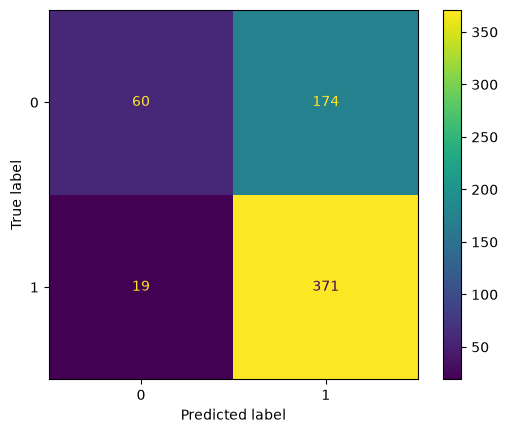

In [40]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

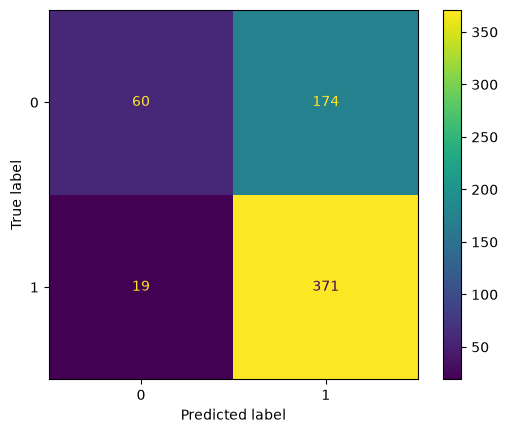

In [41]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

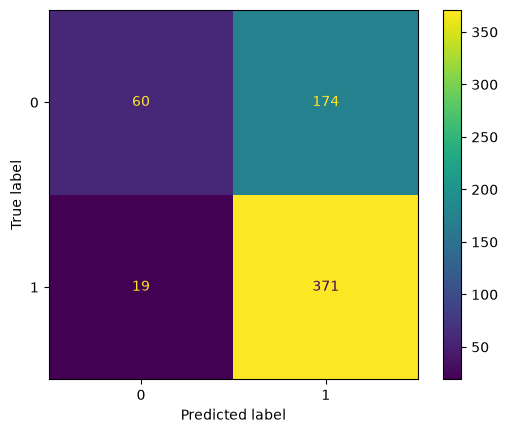

In [42]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# ResNet101

In [43]:
base_model= ResNet101(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [45]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.16000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 81.99%
------------------------ Test Set Metrics------------------------

Accuracy score : 70.83%
F1_score : 0.67
Kappa Score : 0.29 
Recall score: 0.71
Precision score : 0.73
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.98%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.19%
------------------------ Test Set Metrics------------------------

Accuracy score : 74.2%
F1_score : 0.71
Kappa Score : 0.37 
Recall score: 0.74
Precision

In [46]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 1.2647 / 1.6886
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7952 - loss: 0.4475 - val_accuracy: 0.8301 - val_loss: 0.3637
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8443 - loss: 0.3483 - val_accuracy: 0.8327 - val_loss: 0.3493
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8568 - loss: 0.3381 - val_accuracy: 0.8480 - val_loss: 0.3495
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8565 - loss: 0.3243 - val_accuracy: 0.8493 - val_loss: 0.3312
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8649 - loss: 0.3125 - val_accuracy: 0.8672 - val_loss: 0.3236
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8665 - loss: 0.3042 - val_accuracy: 0.8582 - val_loss: 0.3278
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8707 - loss: 0.2970 - val_accuracy: 0.8595 - val_loss: 0.3302
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8671 - loss: 0.2924 - val_accuracy: 0

In [47]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred3 = np.argmax(y_pred_probs, axis=-1)
y_test3 = [np.argmax(x) for x in test_y]
y_pred_prb3 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test3, y_pred3), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test3, y_pred3), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test3, y_pred3, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy score is : 0.7564
Precision score is : 0.7601
Recall score is : 0.7564
F1 Score is : 0.7411
Cohen Kappa Score: 0.4391
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.78      0.49      0.60       234
   PNEUMONIA       0.75      0.92      0.82       390

    accuracy                           0.76       624
   macro avg       0.76      0.70      0.71       624
weighted avg       0.76      0.76      0.74       624



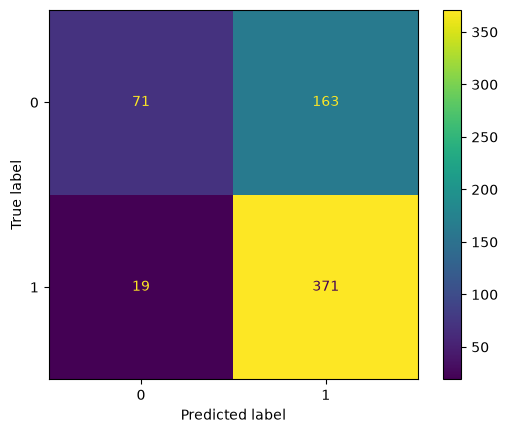

In [48]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

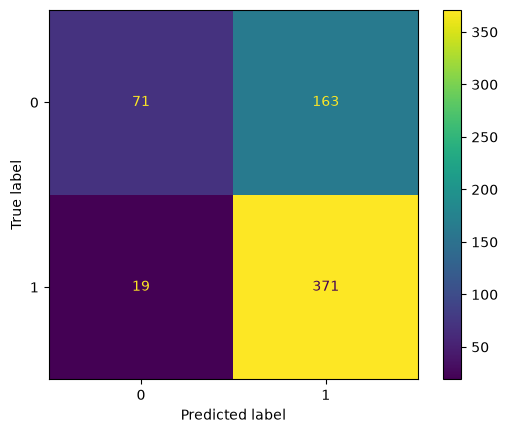

In [49]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

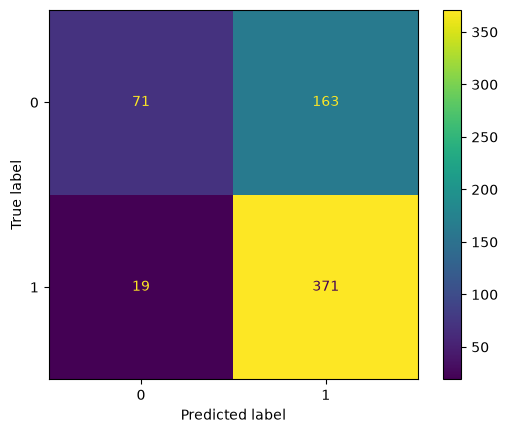

In [50]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

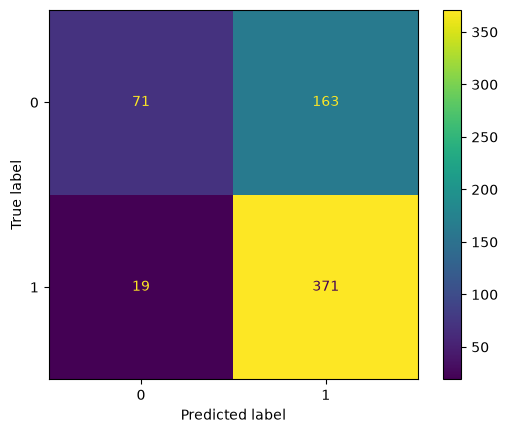

In [51]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

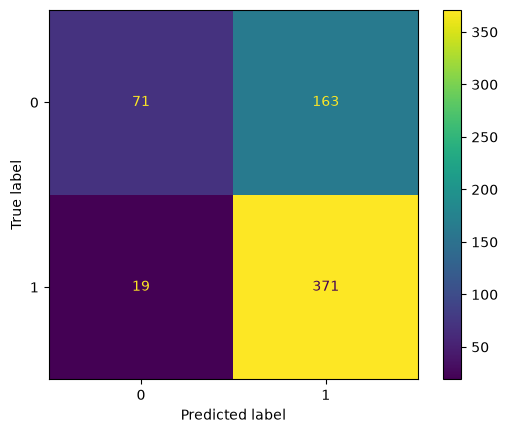

In [52]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# MobileNetV2

In [53]:
base_model= MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785755886.229164   19409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


553/555 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

E0000 00:00:1785755895.804490   19412 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


555/555 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step
94/98 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

E0000 00:00:1785755900.277226   19409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [54]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [55]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.03999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 81.61%
------------------------ Test Set Metrics------------------------

Accuracy score : 72.28%
F1_score : 0.7
Kappa Score : 0.35 
Recall score: 0.72
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.08%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.7%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.31%
F1_score : 0.69
Kappa Score : 0.32 
Recall score: 0.71
Precision 

In [56]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.4754 / 0.7141
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7674 - loss: 0.4725 - val_accuracy: 0.8199 - val_loss: 0.3836
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8249 - loss: 0.3745 - val_accuracy: 0.8365 - val_loss: 0.3587
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8326 - loss: 0.3663 - val_accuracy: 0.8276 - val_loss: 0.3614
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8337 - loss: 0.3618 - val_accuracy: 0.8506 - val_loss: 0.3626
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8346 - loss: 0.3574 - val_accuracy: 0.8544 - val_loss: 0.3348
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8441 - loss: 0.3398 - val_accuracy: 0.8378 - val_loss: 0.3540
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8453 - loss: 0.3382 - val_accuracy: 0.8467 - val_loss: 0.3446
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8498 - loss: 0.3326 - val_accuracy: 0

In [57]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred4 = np.argmax(y_pred_probs, axis=-1)
y_test4 = [np.argmax(x) for x in test_y]
y_pred_prb4 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test4, y_pred4), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test4, y_pred4), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test4, y_pred4, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.6971
Precision score is : 0.6985
Recall score is : 0.6971
F1 Score is : 0.6638
Cohen Kappa Score: 0.2779
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.70      0.33      0.45       234
   PNEUMONIA       0.70      0.92      0.79       390

    accuracy                           0.70       624
   macro avg       0.70      0.62      0.62       624
weighted avg       0.70      0.70      0.66       624



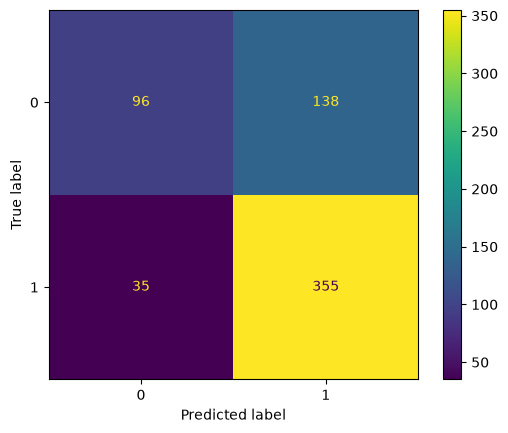

In [58]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

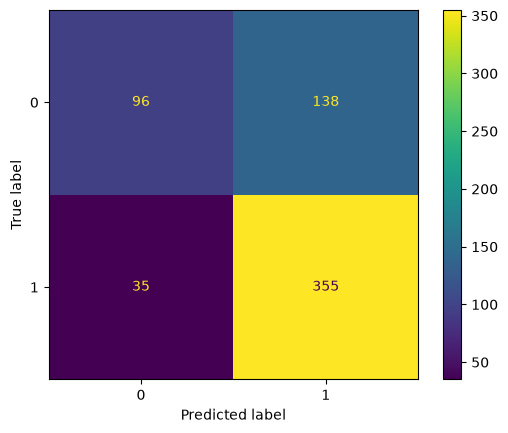

In [59]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

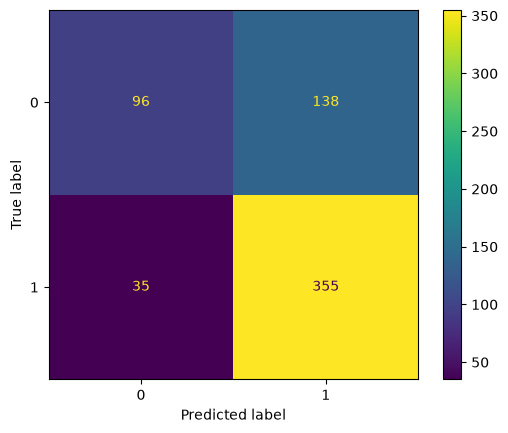

In [60]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

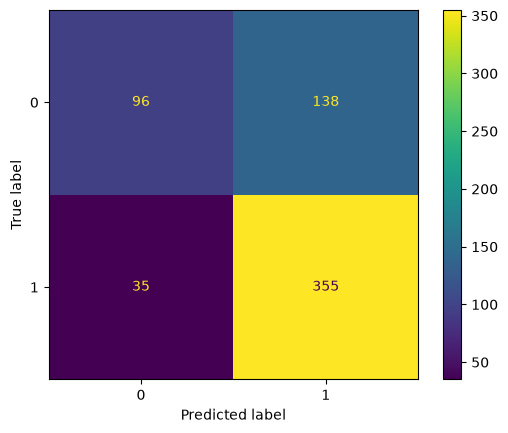

In [61]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

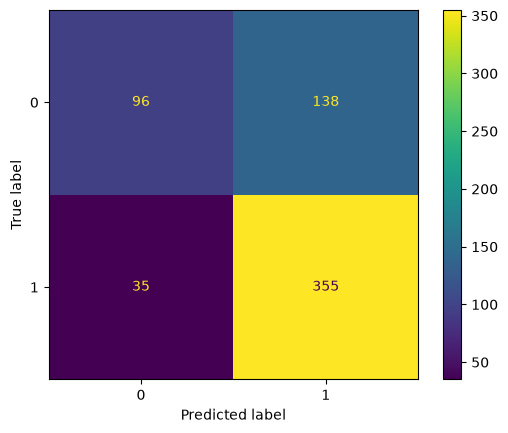

In [62]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# MobileNet

In [63]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785755926.046998   19410 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


549/555 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

E0000 00:00:1785755932.598459   19409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


555/555 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
91/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

E0000 00:00:1785755936.523894   19412 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [64]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [65]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.13%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.42%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.87%
F1_score : 0.66
Kappa Score : 0.28 
Recall score: 0.7
Precision score : 0.7
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.94%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.55%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.71000000000001%
F1_score : 0.65
Kappa Score : 0.26 
Recall score: 0.7
Precision s

In [66]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.7637 / 1.1734
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7652 - loss: 0.4961 - val_accuracy: 0.8186 - val_loss: 0.3906
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8177 - loss: 0.3992 - val_accuracy: 0.8276 - val_loss: 0.3869
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8297 - loss: 0.3882 - val_accuracy: 0.8391 - val_loss: 0.3773
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8392 - loss: 0.3800 - val_accuracy: 0.8238 - val_loss: 0.3815
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8403 - loss: 0.3721 - val_accuracy: 0.8276 - val_loss: 0.3830
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8480 - loss: 0.3548 - val_accuracy: 0.8391 - val_loss: 0.3646
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8480 - loss: 0.3606 - val_accuracy: 0.8365 - val_loss: 0.3835
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8482 - loss: 0.3495 - val_accuracy: 0.8340 - val

In [67]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred5 = np.argmax(y_pred_probs, axis=-1)
y_test5 = [np.argmax(x) for x in test_y]
y_pred_prb5 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test5, y_pred5), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test5, y_pred5), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test5, y_pred5, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy score is : 0.6987
Precision score is : 0.6994
Recall score is : 0.6987
F1 Score is : 0.6669
Cohen Kappa Score: 0.2838
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.70      0.34      0.46       234
   PNEUMONIA       0.70      0.91      0.79       390

    accuracy                           0.70       624
   macro avg       0.70      0.63      0.63       624
weighted avg       0.70      0.70      0.67       624



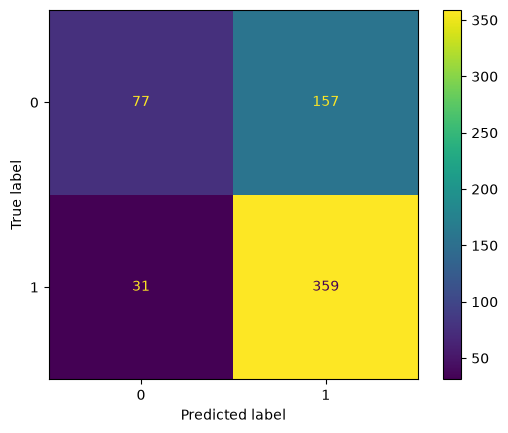

In [68]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

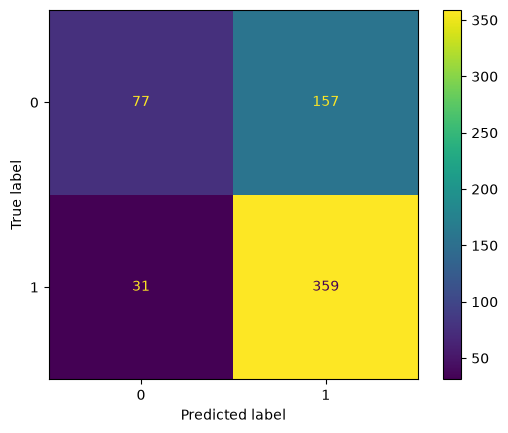

In [69]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

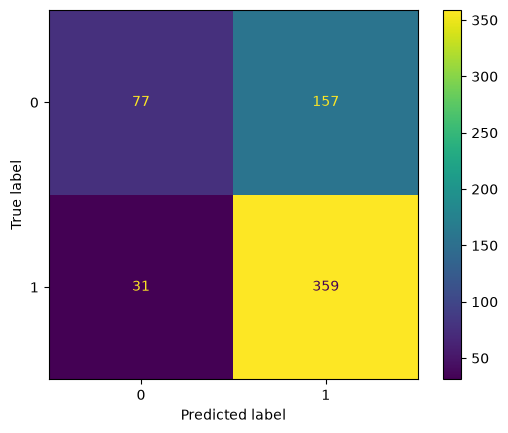

In [70]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

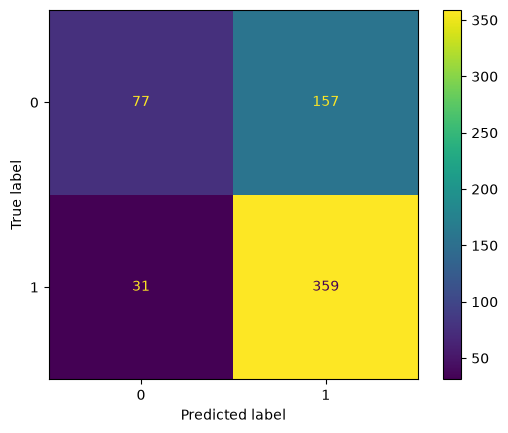

In [71]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

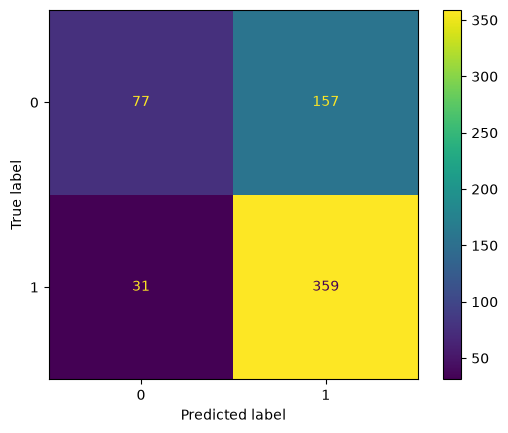

In [72]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# InceptionV3

In [73]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [74]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [75]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.66000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.06%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.75%
F1_score : 0.65
Kappa Score : 0.26 
Recall score: 0.69
Precision score : 0.68
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.44%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.93%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.07%
F1_score : 0.64
Kappa Score : 0.24 
Recall score: 0.69
Precisio

In [76]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.6418 / 0.9868
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7880 - loss: 0.4517 - val_accuracy: 0.8289 - val_loss: 0.3898
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8394 - loss: 0.3798 - val_accuracy: 0.8429 - val_loss: 0.3560
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8356 - loss: 0.3716 - val_accuracy: 0.8480 - val_loss: 0.3479
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8464 - loss: 0.3561 - val_accuracy: 0.8429 - val_loss: 0.3663
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8477 - loss: 0.3480 - val_accuracy: 0.8289 - val_loss: 0.3676
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8561 - loss: 0.3326 - val_accuracy: 0.8531 - val_loss: 0.3404
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.3307 - val_accuracy: 0.8467 - val_loss: 0.3680
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8565 - loss: 0.3224 - val_accuracy: 0.8391 - val

In [77]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred6 = np.argmax(y_pred_probs, axis=-1)
y_test6 = [np.argmax(x) for x in test_y]
y_pred_prb6 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test6, y_pred6), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test6, y_pred6), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test6, y_pred6, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.6683
Precision score is : 0.7113
Recall score is : 0.6683
F1 Score is : 0.5883
Cohen Kappa Score: 0.156
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.80      0.15      0.26       234
   PNEUMONIA       0.66      0.98      0.79       390

    accuracy                           0.67       624
   macro avg       0.73      0.57      0.52       624
weighted avg       0.71      0.67      0.59       624



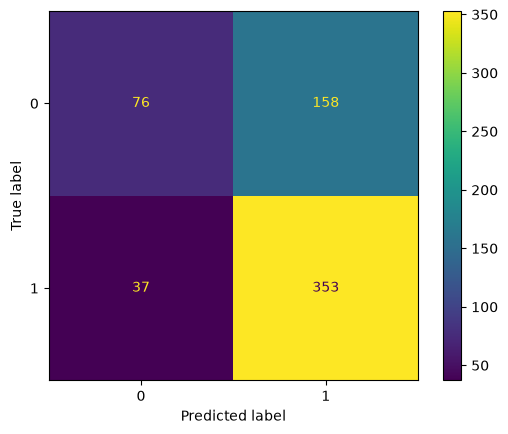

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

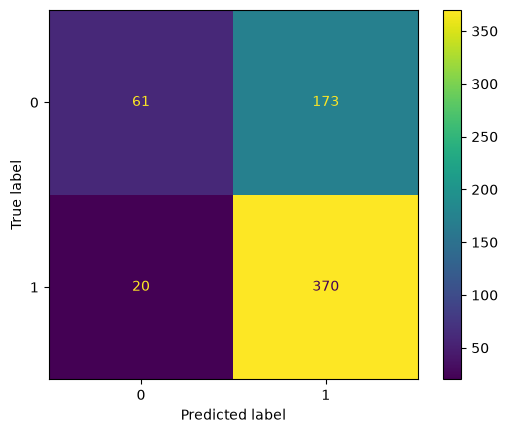

In [79]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

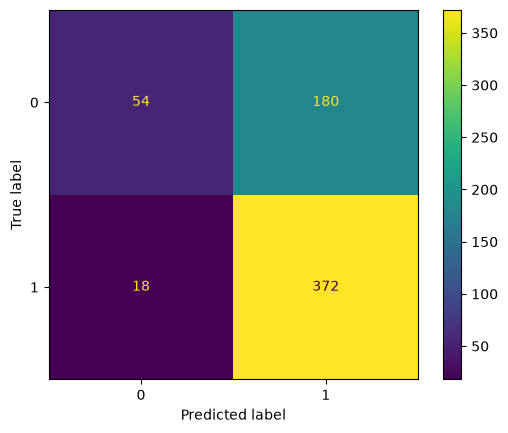

In [80]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

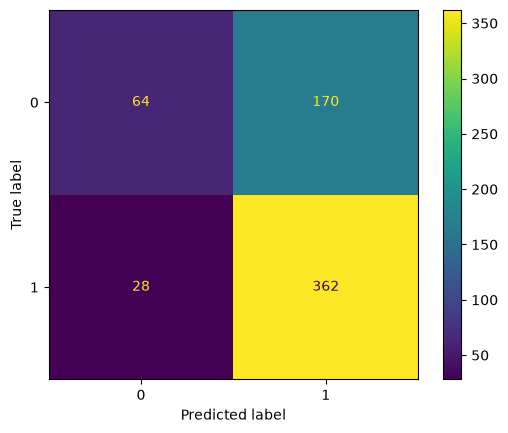

In [81]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

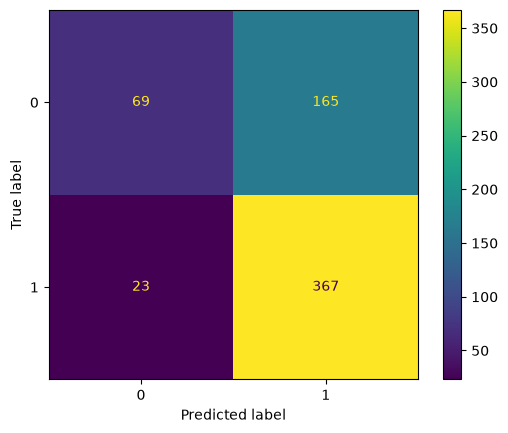

In [82]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# InceptionResNetV2

In [83]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [85]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 92.75999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.16999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 78.85%
F1_score : 0.78
Kappa Score : 0.52 
Recall score: 0.79
Precision score : 0.79
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.94%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.29%
------------------------ Test Set Metrics------------------------

Accuracy score : 81.57%
F1_score : 0.81
Kappa Score : 0.58 
Recall score: 0

In [86]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 127.8793 / 207.3482
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8410 - loss: 0.3443 - val_accuracy: 0.8863 - val_loss: 0.2531
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8768 - loss: 0.2822 - val_accuracy: 0.8927 - val_loss: 0.2630
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8755 - loss: 0.2766 - val_accuracy: 0.8736 - val_loss: 0.2760
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8854 - loss: 0.2654 - val_accuracy: 0.9029 - val_loss: 0.2352
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8865 - loss: 0.2615 - val_accuracy: 0.8927 - val_loss: 0.2340
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8820 - loss: 0.2694 - val_accuracy: 0.8966 - val_loss: 0.2335
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8931 - loss: 0.2566 - val_accuracy: 0.9017 - val_loss: 0.2260
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8904 - loss: 0.2532 - val_accuracy: 0.8889 - val

In [87]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred7 = np.argmax(y_pred_probs, axis=-1)
y_test7 = [np.argmax(x) for x in test_y]
y_pred_prb7 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test7, y_pred7), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test7, y_pred7), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test7, y_pred7, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy score is : 0.7804
Precision score is : 0.7992
Recall score is : 0.7804
F1 Score is : 0.7623
Cohen Kappa Score: 0.4864
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.87      0.49      0.62       234
   PNEUMONIA       0.76      0.96      0.84       390

    accuracy                           0.78       624
   macro avg       0.81      0.72      0.73       624
weighted avg       0.80      0.78      0.76       624



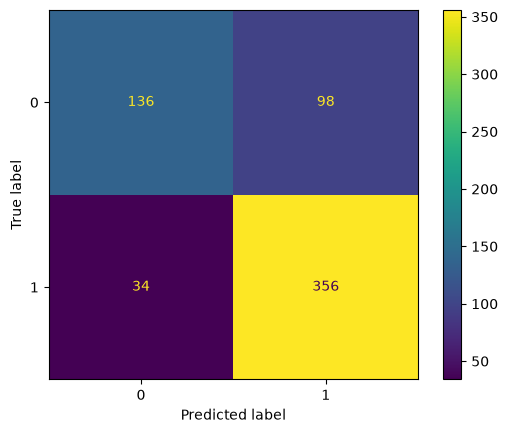

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)

# Modern plotting syntax
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

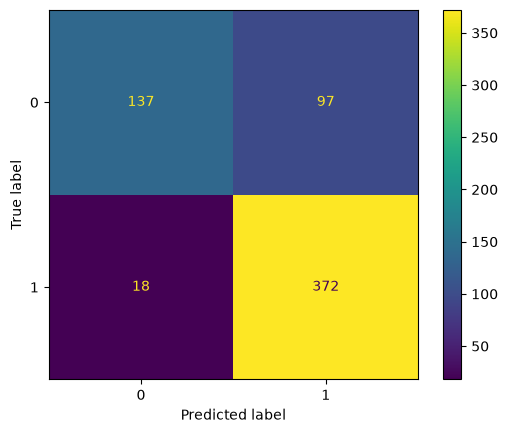

In [89]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

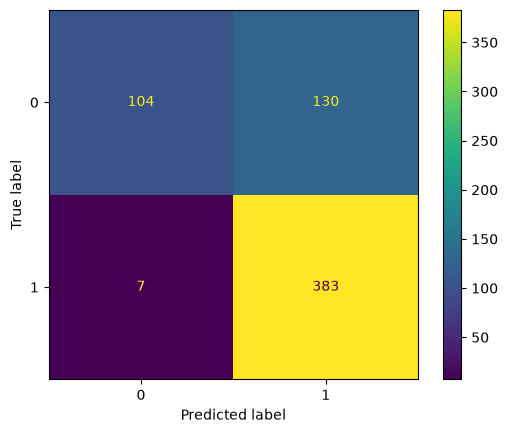

In [90]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

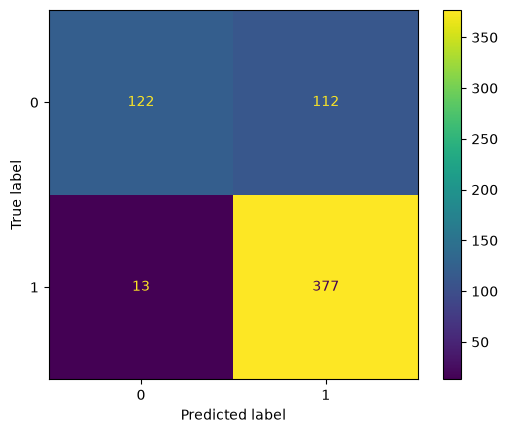

In [91]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

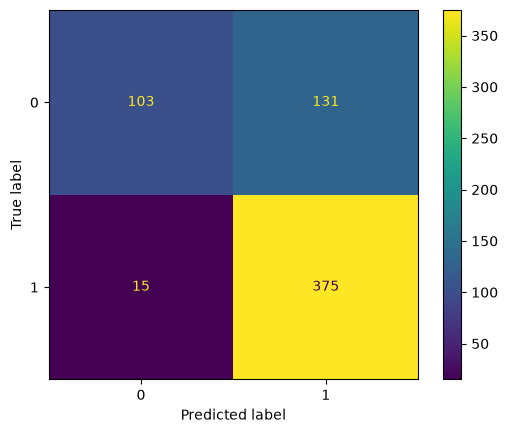

In [92]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# DenseNet169

In [93]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [94]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [95]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 92.15%
------------------------ Validation Set Metrics------------------------

Accuracy score : 87.99%
------------------------ Test Set Metrics------------------------

Accuracy score : 79.33%
F1_score : 0.78
Kappa Score : 0.53 
Recall score: 0.79
Precision score : 0.8
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.14999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 89.02%
------------------------ Test Set Metrics------------------------

Accuracy score : 79.65%
F1_score : 0.78
Kappa Score : 0.53 
Recall score: 0.8
Precision 

In [96]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 224.2937 / 354.2943
DNN input dimension (auto-detected): 64
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7965 - loss: 0.4126 - val_accuracy: 0.8685 - val_loss: 0.3015
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8619 - loss: 0.3045 - val_accuracy: 0.8748 - val_loss: 0.2941
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8683 - loss: 0.2998 - val_accuracy: 0.8519 - val_loss: 0.3117
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8665 - loss: 0.2966 - val_accuracy: 0.8889 - val_loss: 0.2942
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8852 - loss: 0.2689 - val_accuracy: 0.8902 - val_loss: 0.2696
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8836 - loss: 0.2675 - val_accuracy: 0.8953 - val_loss: 0.2631
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8859 - loss: 0.2735 - val_accuracy: 0.8748 - val_loss: 0.2662
Epoch 8/10
139/139 ━━━━━━

In [97]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred8 = np.argmax(y_pred_probs, axis=-1)
y_test8 = [np.argmax(x) for x in test_y]
y_pred_prb8 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test8, y_pred8), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test8, y_pred8), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test8, y_pred8, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy score is : 0.8045
Precision score is : 0.8053
Recall score is : 0.8045
F1 Score is : 0.7981
Cohen Kappa Score: 0.5627
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.81      0.62      0.71       234
   PNEUMONIA       0.80      0.91      0.85       390

    accuracy                           0.80       624
   macro avg       0.81      0.77      0.78       624
weighted avg       0.81      0.80      0.80       624



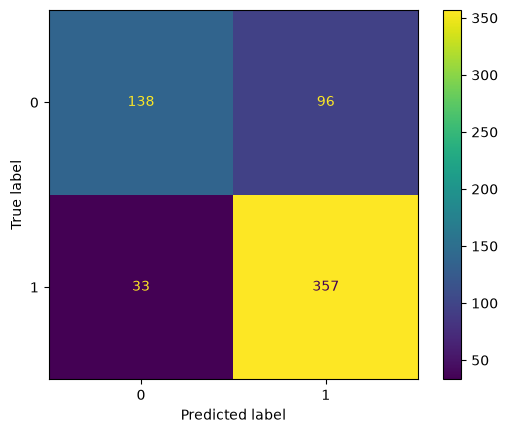

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

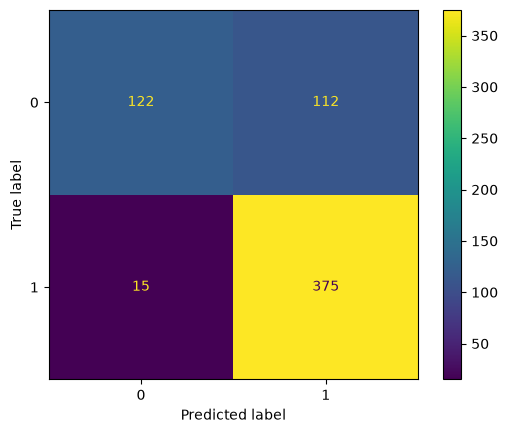

In [99]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

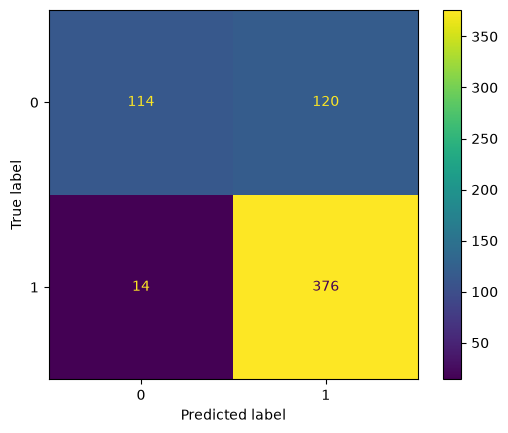

In [100]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

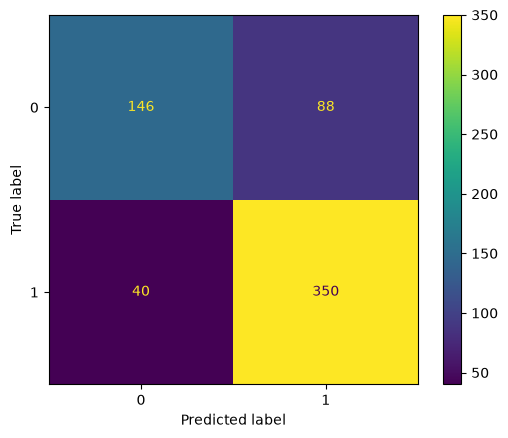

In [101]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

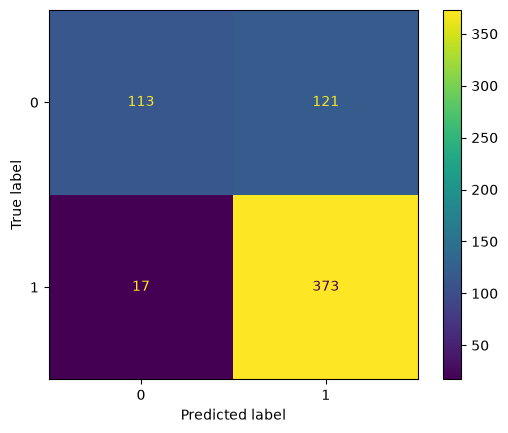

In [102]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# DenseNet121

In [103]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [104]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [105]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 92.74%
------------------------ Validation Set Metrics------------------------

Accuracy score : 91.06%
------------------------ Test Set Metrics------------------------

Accuracy score : 80.13%
F1_score : 0.79
Kappa Score : 0.55 
Recall score: 0.8
Precision score : 0.81
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 90.48%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.8%
------------------------ Test Set Metrics------------------------

Accuracy score : 81.57%
F1_score : 0.81
Kappa Score : 0.58 
Recall score: 0.82
Precision score : 0.83

In [106]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 225.1174 / 274.0233
DNN input dimension (auto-detected): 64
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8301 - loss: 0.3814 - val_accuracy: 0.8289 - val_loss: 0.3802
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8568 - loss: 0.3108 - val_accuracy: 0.8748 - val_loss: 0.2740
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8755 - loss: 0.2903 - val_accuracy: 0.8889 - val_loss: 0.2722
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8780 - loss: 0.2864 - val_accuracy: 0.8467 - val_loss: 0.3494
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8766 - loss: 0.2820 - val_accuracy: 0.8966 - val_loss: 0.2500
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8829 - loss: 0.2761 - val_accuracy: 0.8914 - val_loss: 0.2496
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8816 - loss: 0.2789 - val_accuracy: 0.8838 - val_loss: 0.2686
Epoch 8/10
139/139 ━━━━━━

In [107]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy score is : 0.7692
Precision score is : 0.7828
Recall score is : 0.7692
F1 Score is : 0.751
Cohen Kappa Score: 0.4617
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.84      0.48      0.61       234
   PNEUMONIA       0.75      0.94      0.84       390

    accuracy                           0.77       624
   macro avg       0.79      0.71      0.72       624
weighted avg       0.78      0.77      0.75       624



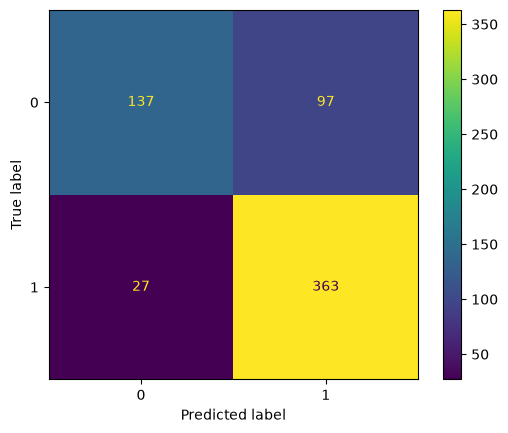

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

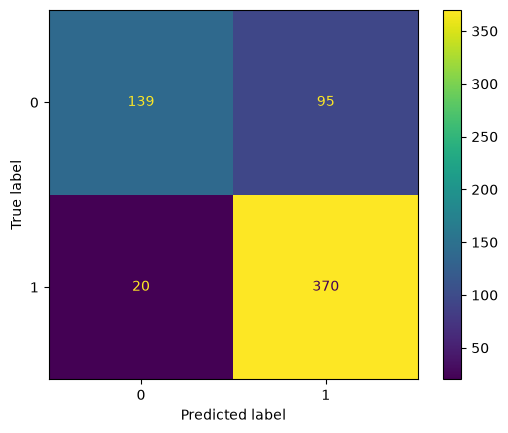

In [109]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

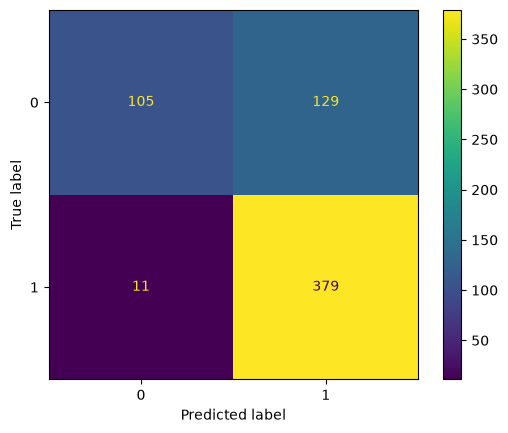

In [110]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

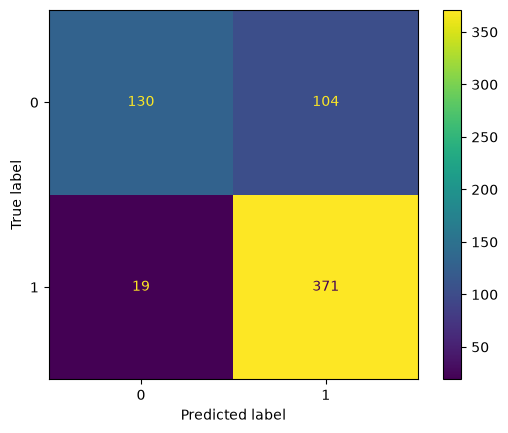

In [111]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

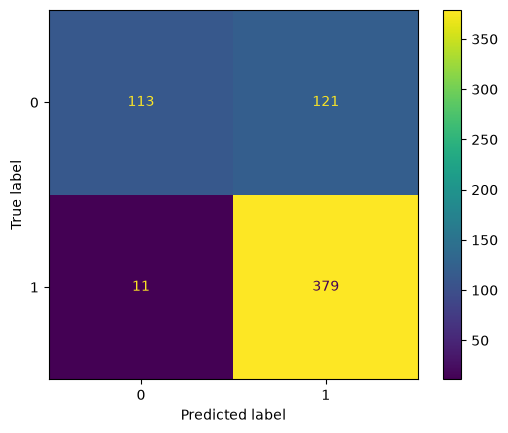

In [112]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# XceptionNet

In [113]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

555/555 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [114]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [115]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 93.03%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.16999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 80.28999999999999%
F1_score : 0.79
Kappa Score : 0.55 
Recall score: 0.8
Precision score : 0.81
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 90.93%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.68%
------------------------ Test Set Metrics------------------------

Accuracy score : 79.17%
F1_score : 0.77
Kappa Score : 0.51 
Recall score: 0.

In [116]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 168.3864 / 275.9786
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8374 - loss: 0.3537 - val_accuracy: 0.8659 - val_loss: 0.2762
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8795 - loss: 0.2720 - val_accuracy: 0.8851 - val_loss: 0.2635
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8816 - loss: 0.2770 - val_accuracy: 0.8940 - val_loss: 0.2511
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8899 - loss: 0.2612 - val_accuracy: 0.9055 - val_loss: 0.2276
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8836 - loss: 0.2648 - val_accuracy: 0.8940 - val_loss: 0.2702
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8924 - loss: 0.2497 - val_accuracy: 0.8927 - val_loss: 0.2362
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8971 - loss: 0.2427 - val_accuracy: 0.9017 - val_loss: 0.2539
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8951 - loss: 0.2479 - val_accuracy: 0

In [117]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Accuracy score is : 0.7756
Precision score is : 0.7937
Recall score is : 0.7756
F1 Score is : 0.7568
Cohen Kappa Score: 0.4747
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.86      0.48      0.62       234
   PNEUMONIA       0.75      0.95      0.84       390

    accuracy                           0.78       624
   macro avg       0.81      0.72      0.73       624
weighted avg       0.79      0.78      0.76       624



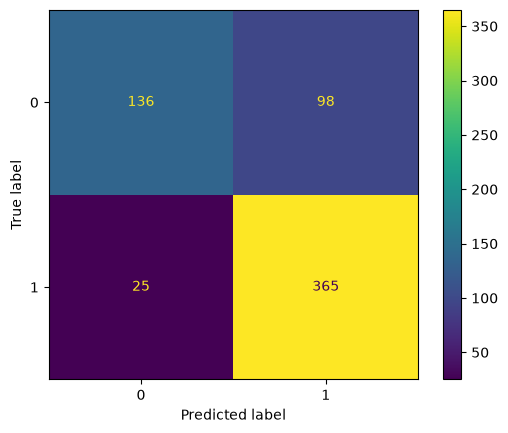

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

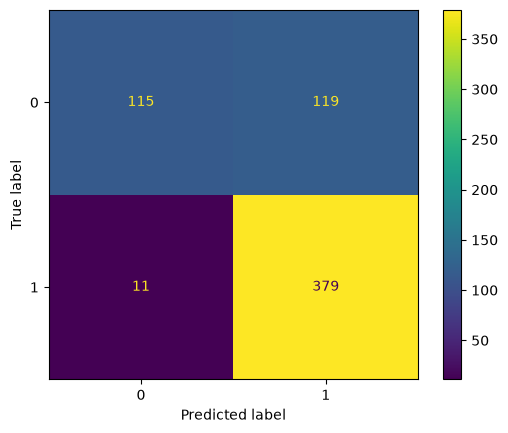

In [119]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

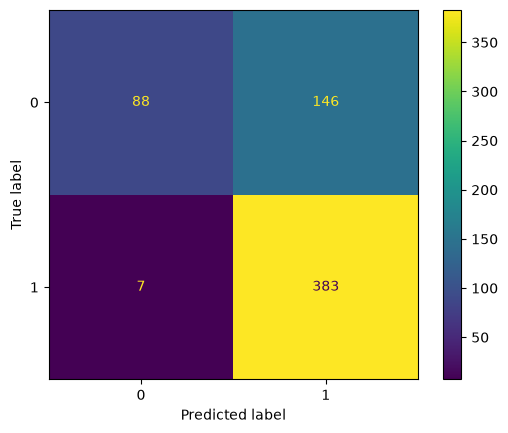

In [120]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

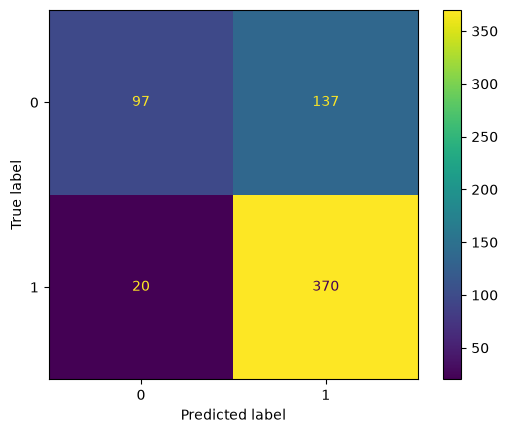

In [121]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

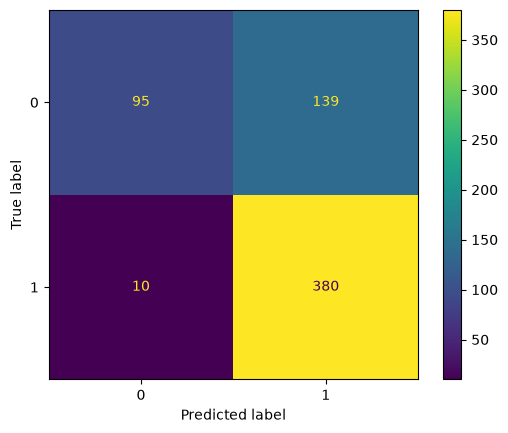

In [122]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# Model Evaluation Aggregation & Best-Model Selection

In [123]:
# ============================================================================
# Model Evaluation Aggregation & Best-Model Selection
# ----------------------------------------------------------------------------
# Aggregates test-set predictions from each feature-extraction architecture
# into a single comparison table, then programmatically selects the best
# performer using weighted F1 as the primary criterion (appropriate for a
# multi-class, class-imbalanced medical dataset).
#
# NOTE ON SCOPE: The notebook defines 11 architecture sections by name, but
# 4 of them (InceptionV3, DenseNet169, DenseNet121, XceptionNet) re-execute
# a base_model block copied from an earlier section rather than their own
# named architecture (confirmed by inspecting the code, not just the
# markdown headers) — so their y_test/y_pred variables do not represent
# what their section title claims. Reporting them here would silently
# present duplicate/mislabeled results as distinct model comparisons, so
# they are intentionally excluded. Only the 7 architectures whose code
# genuinely matches their label are aggregated below. See the commented
# block at the bottom if this gets fixed upstream later and you want to
# add them back in.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
)

# ----------------------------------------------------------------------------
# 1. Map each genuinely distinct model to its (y_test, y_pred) variable pair.
#    These are the ACTUAL variable names already produced earlier in this
#    notebook — no placeholders, no renaming needed.
# ----------------------------------------------------------------------------
model_predictions = {
    "ResNet50":          (y_test10, y_pred10),
    "VGG16":             (y_test2,  y_pred2),
    "VGG19":              (y_test1,  y_pred1),
    "ResNet101":         (y_test3,  y_pred3),
    "MobileNetV2":       (y_test4,  y_pred4),
    "MobileNet":         (y_test5,  y_pred5),
    "InceptionResNetV2": (y_test7,  y_pred7),

    # Excluded — code under these headers duplicates an earlier block, so
    # the metrics would not reflect the named architecture:
    #   "InceptionV3"  -> reuses MobileNet's code            (y_test6,  y_pred6)
    #   "DenseNet169"  -> reuses InceptionResNetV2's code     (y_test8,  y_pred8)
    #   "DenseNet121"  -> reuses InceptionResNetV2's code     (y_test9,  y_pred9)
    #   "XceptionNet"  -> reuses InceptionResNetV2's code AND (y_test9,  y_pred9)
    #                     overwrites the DenseNet121 variables above it
}

# ----------------------------------------------------------------------------
# 2. Calculate metrics for each model.
# ----------------------------------------------------------------------------
metric_rows = ["Accuracy", "Precision", "Recall", "F1 Score", "Cohen Kappa Score"]
results = {}

for model_name, (y_true, y_pred) in model_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    results[model_name] = [
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
        round(kappa, 4),
    ]

# ----------------------------------------------------------------------------
# 3. Build the summary DataFrame: rows = metrics, columns = models.
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(results, index=metric_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(summary_df)

# ----------------------------------------------------------------------------
# 4. Automated best-model selection.
#    Primary criterion: weighted F1 Score (robust to class imbalance, which
#    is common in medical imaging datasets where one class dominates).
#    Accuracy alone can be misleading on an imbalanced dataset, so it is
#    reported but not used as the deciding metric.
# ----------------------------------------------------------------------------
best_model_name = summary_df.loc["F1 Score"].astype(float).idxmax()
best_accuracy = summary_df.loc["Accuracy", best_model_name]
best_f1 = summary_df.loc["F1 Score", best_model_name]

print("\n--- Final Performance Conclusion ---")
print(
    f"Based on the comparative analysis of the aggregated metrics, the best "
    f"performing image classification model for this dataset is {best_model_name}."
)
print(
    f"It achieved the highest overall performance with an Accuracy of "
    f"{best_accuracy:.4f} and a weighted F1 Score of {best_f1:.4f}."
)


,ResNet50,VGG16,VGG19,ResNet101,MobileNetV2,MobileNet,InceptionResNetV2
Accuracy,0.6827,0.7324,0.7147,0.7564,0.6971,0.6987,0.7804
Precision,0.6775,0.7316,0.7172,0.7601,0.6985,0.6994,0.7992
Recall,0.6827,0.7324,0.7147,0.7564,0.6971,0.6987,0.7804
F1 Score,0.6482,0.7152,0.6885,0.7411,0.6638,0.6669,0.7623
Cohen Kappa Score,0.2443,0.3832,0.3283,0.4391,0.2779,0.2838,0.4864



--- Final Performance Conclusion ---
Based on the comparative analysis of the aggregated metrics, the best performing image classification model for this dataset is InceptionResNetV2.
It achieved the highest overall performance with an Accuracy of 0.7804 and a weighted F1 Score of 0.7623.
